# 10 – Anti-Windup

**Manufacturing context:** When an actuator saturates, the integral term keeps accumulating error even though the output is clamped. This **integrator windup** causes large overshoot when the error eventually reverses.

**Fix:** Conditional integration — stop accumulating when the actuator is saturated.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ---- Editable parameters ----
m = 1.0
c = 1.0
k = 4.0
ref = 1.0
t_end = 10.0
dt = 0.001

Kp = 30.0
Ki = 15.0
Kd = 8.0

u_min = -50.0
u_max = 50.0
# -----------------------------

In [2]:
t = np.arange(0, t_end, dt)

def simulate_pid_aw(Kp, Ki, Kd, u_min, u_max, anti_windup=False):
    x = np.zeros_like(t)
    v = np.zeros_like(t)
    u = np.zeros_like(t)
    integral_e = 0.0
    prev_e = 0.0

    for i in range(1, len(t)):
        e = ref - x[i-1]
        integral_e += e * dt
        derivative_e = (e - prev_e) / dt

        u_raw = Kp * e + Ki * integral_e + Kd * derivative_e
        u_applied = np.clip(u_raw, u_min, u_max)

        # Anti-windup: undo integration when saturated
        if anti_windup and u_applied != u_raw:
            integral_e -= e * dt

        u[i] = u_applied
        prev_e = e

        a = (u[i] - c * v[i-1] - k * x[i-1]) / m
        v[i] = v[i-1] + a * dt
        x[i] = x[i-1] + v[i] * dt

    return x, u

x_noaw, u_noaw = simulate_pid_aw(Kp, Ki, Kd, u_min, u_max, anti_windup=False)
x_aw, u_aw = simulate_pid_aw(Kp, Ki, Kd, u_min, u_max, anti_windup=True)

print(f"Overshoot (no anti-windup)   : {(np.max(x_noaw) - ref) / ref * 100:.1f}%")
print(f"Overshoot (with anti-windup) : {(np.max(x_aw) - ref) / ref * 100:.1f}%")

Overshoot (no anti-windup)   : 2.7%
Overshoot (with anti-windup) : 2.6%


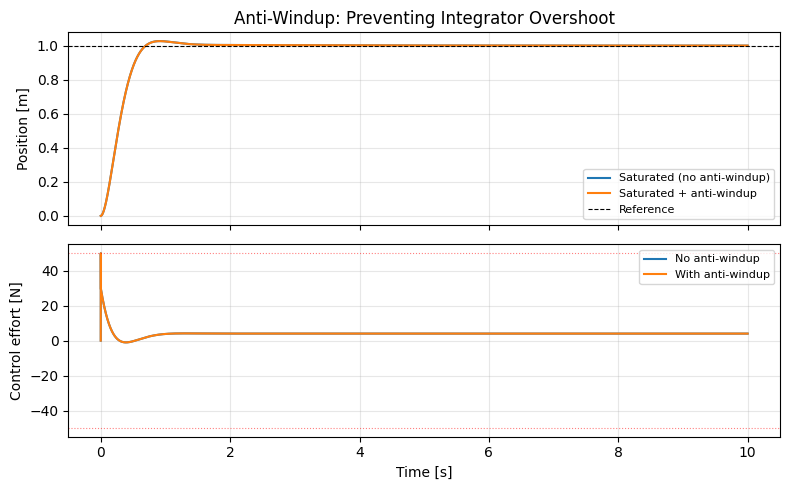

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)

axes[0].plot(t, x_noaw, label="Saturated (no anti-windup)")
axes[0].plot(t, x_aw, label="Saturated + anti-windup")
axes[0].axhline(ref, color="k", linestyle="--", linewidth=0.8, label="Reference")
axes[0].set_ylabel("Position [m]")
axes[0].set_title("Anti-Windup: Preventing Integrator Overshoot")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, u_noaw, label="No anti-windup")
axes[1].plot(t, u_aw, label="With anti-windup")
axes[1].axhline(u_max, color="r", linestyle=":", linewidth=0.8, alpha=0.5)
axes[1].axhline(u_min, color="r", linestyle=":", linewidth=0.8, alpha=0.5)
axes[1].set_ylabel("Control effort [N]")
axes[1].set_xlabel("Time [s]")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

### Student Exercise

1. Tighten the limits to `u_max=20`. Does anti-windup matter more or less with tighter limits?
2. Set `Ki = 50.0`. How severe does windup become without the fix?
3. Most industrial servo drives have a built-in anti-windup setting. Why is it on by default?